# CSIT 598 - Assignment 1
## 03. Naive Bayes (Gaussian vs Multinomial)

Implementation of both Naive Bayes variants and their comparison on  performance
1) GaussianNB
2) MultinomialNB

Artifacts consumed: `results/metrics/mnist_splits.npz`

In [6]:
from pathlib import Path
import json
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB

from utils import evaluate_classifier, plot_confusion

In [7]:
project_root = Path.cwd().parent
artifact_path = project_root / 'results' / 'metrics' / 'mnist_splits.npz'

if not artifact_path.exists():
    raise FileNotFoundError(
        f"Missing artifact: {artifact_path}. Run 01_data_preprocessing.ipynb first."
    )

data = dict(np.load(artifact_path))

X_train_norm, y_train = data['X_train'], data['y_train']
X_val_norm, y_val = data['X_val'], data['y_val']
X_test_norm, y_test = data['X_test'], data['y_test']

X_train_std = data['X_train_std']
X_val_std = data['X_val_std']
X_test_std = data['X_test_std']

print('Loaded data shapes:')
print(f'Normalized train: {X_train_norm.shape}, val: {X_val_norm.shape}, test: {X_test_norm.shape}')
print(f'Standardized train: {X_train_std.shape}, val: {X_val_std.shape}, test: {X_test_std.shape}')

Loaded data shapes:
Normalized train: (50000, 784), val: (10000, 784), test: (10000, 784)
Standardized train: (50000, 784), val: (10000, 784), test: (10000, 784)


In [8]:
# GaussianNB on standardized features
gaussian_model = GaussianNB()
gaussian_metrics = evaluate_classifier(
    gaussian_model, X_train_std, y_train, X_test_std, y_test
)

print('GaussianNB Test Metrics:')
print(f"Accuracy: {gaussian_metrics['accuracy']:.4f}")
print(f"Precision (macro): {gaussian_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {gaussian_metrics['recall_macro']:.4f}")
print(f"F1 (macro): {gaussian_metrics['f1_macro']:.4f}")
print(f"Train time (s): {gaussian_metrics['train_time_sec']:.2f}")
print(f"Pred time (s): {gaussian_metrics['pred_time_sec']:.2f}")

GaussianNB Test Metrics:
Accuracy: 0.5359
Precision (macro): 0.6691
Recall (macro): 0.5283
F1 (macro): 0.4754
Train time (s): 0.09
Pred time (s): 0.04


In [9]:
# MultinomialNB on normalized non-negative features
alpha_grid = {'alpha': [0.1, 0.5, 1.0, 2.0]}

multinomial_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=alpha_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1,
 )
multinomial_search.fit(X_train_norm, y_train)

print('Best MultinomialNB params:', multinomial_search.best_params_)
print(f"Best CV accuracy: {multinomial_search.best_score_:.4f}")

multinomial_model = MultinomialNB(**multinomial_search.best_params_)
multinomial_metrics = evaluate_classifier(
    multinomial_model, X_train_norm, y_train, X_test_norm, y_test
)

print('\nMultinomialNB Test Metrics:')
print(f"Accuracy: {multinomial_metrics['accuracy']:.4f}")
print(f"Precision (macro): {multinomial_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {multinomial_metrics['recall_macro']:.4f}")
print(f"F1 (macro): {multinomial_metrics['f1_macro']:.4f}")
print(f"Train time (s): {multinomial_metrics['train_time_sec']:.2f}")
print(f"Pred time (s): {multinomial_metrics['pred_time_sec']:.2f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best MultinomialNB params: {'alpha': 0.1}
Best CV accuracy: 0.8246

MultinomialNB Test Metrics:
Accuracy: 0.8307
Precision (macro): 0.8364
Recall (macro): 0.8275
F1 (macro): 0.8290
Train time (s): 0.02
Pred time (s): 0.02


Gaussian classification report:

              precision    recall  f1-score   support

           0       0.68      0.92      0.78       986
           1       0.80      0.95      0.87      1125
           2       0.88      0.22      0.35       999
           3       0.72      0.24      0.36      1020
           4       0.84      0.12      0.21       975
           5       0.48      0.02      0.05       902
           6       0.71      0.91      0.79       982
           7       0.93      0.26      0.40      1042
           8       0.26      0.71      0.38       975
           9       0.40      0.94      0.56       994

    accuracy                           0.54     10000
   macro avg       0.67      0.53      0.48     10000
weighted avg       0.67      0.54      0.48     10000


Multinomial classification report:

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       986
           1       0.88      0.94      0.91      1125
        

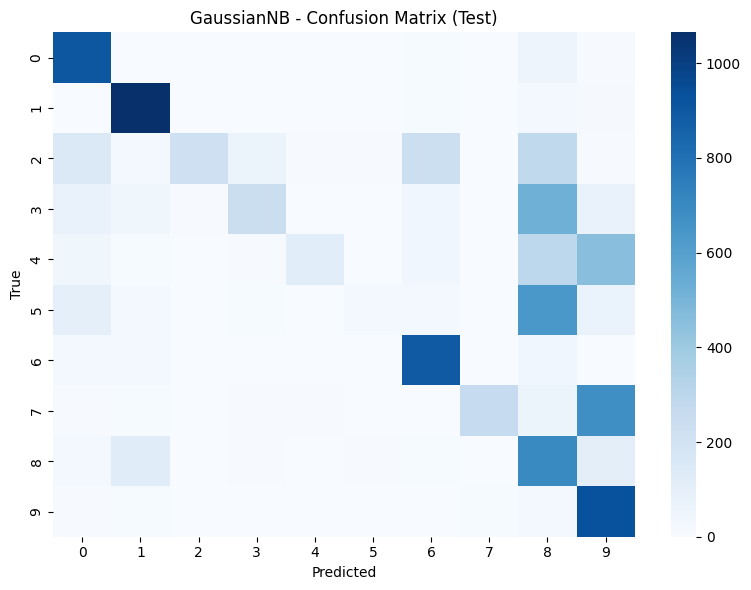

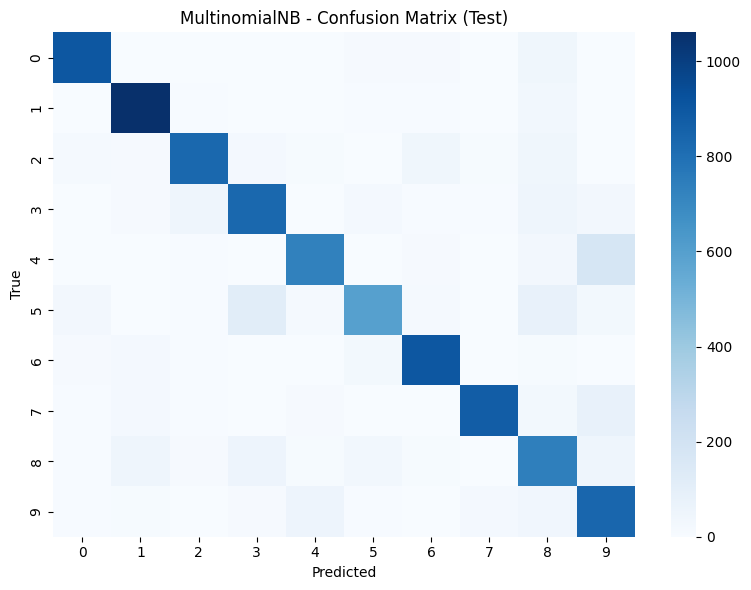


Saved:
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/gaussian_nb_metrics.json
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/multinomial_nb_metrics.json
/Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/naive_bayes_comparison.json


In [10]:
# Save metrics, plot confusion matrices, and summarize observations
metrics_dir = project_root / 'results' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

gaussian_to_save = {k: v for k, v in gaussian_metrics.items() if k != 'y_pred'}
gaussian_to_save['model_name'] = 'GaussianNB'

multinomial_to_save = {k: v for k, v in multinomial_metrics.items() if k != 'y_pred'}
multinomial_to_save['model_name'] = 'MultinomialNB'
multinomial_to_save['best_params'] = multinomial_search.best_params_

with open(metrics_dir / 'gaussian_nb_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(gaussian_to_save, f, indent=2)

with open(metrics_dir / 'multinomial_nb_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(multinomial_to_save, f, indent=2)

comparison = {
    'gaussian_accuracy': gaussian_metrics['accuracy'],
    'multinomial_accuracy': multinomial_metrics['accuracy'],
    'accuracy_delta_multinomial_minus_gaussian': multinomial_metrics['accuracy'] - gaussian_metrics['accuracy'],
}
with open(metrics_dir / 'naive_bayes_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(comparison, f, indent=2)

print('Gaussian classification report:\n')
print(gaussian_metrics['classification_report'])
print('\nMultinomial classification report:\n')
print(multinomial_metrics['classification_report'])

print('\nObservation:')
if multinomial_metrics['accuracy'] >= gaussian_metrics['accuracy']:
    print('MultinomialNB outperforms or matches GaussianNB on MNIST in this run.')
else:
    print('GaussianNB outperforms MultinomialNB on MNIST in this run.')
print(f"Accuracy delta (Multinomial - Gaussian): {comparison['accuracy_delta_multinomial_minus_gaussian']:.4f}")

plot_confusion(y_test, gaussian_metrics['y_pred'], title='GaussianNB - Confusion Matrix (Test)')
plot_confusion(y_test, multinomial_metrics['y_pred'], title='MultinomialNB - Confusion Matrix (Test)')

print('\nSaved:')
print(metrics_dir / 'gaussian_nb_metrics.json')
print(metrics_dir / 'multinomial_nb_metrics.json')
print(metrics_dir / 'naive_bayes_comparison.json')